In [1]:
# --- run me first ---

from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')  # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))  # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


# AAPL Volatility Forecasting — Project Pipeline

This persistent notebook begins the end-to-end project pipeline and will be extended in later lifecycle stages. Stage 04 acquires and validates the trusted raw market-data snapshot.

## Stage 04 — Data acquisition and ingestion

**Source:** Yahoo Finance, accessed programmatically through the open-source `yfinance` client.  
**Dataset:** Unadjusted daily AAPL open, high, low, close, adjusted close, and volume.  
**Parameters:** Ticker and exclusive date bounds come from the local `.env`; the committed `.env.example` documents safe defaults.  
**Raw-data policy:** Preserve the vendor values and append only provenance columns. The filename records the actual minimum and maximum observation dates, so reruns over the same response replace the same snapshot rather than creating timestamp clutter.

In [2]:
import pandas as pd

from src.config import get_key, get_path, load_env
from src.ingestion import fetch_daily_ohlcv, save_raw_snapshot, validate_daily_ohlcv

if not load_env():
    raise FileNotFoundError('Create project/.env from .env.example before running the pipeline.')

SYMBOL = get_key('MARKET_DATA_TICKER', 'AAPL', required=True)
START_DATE = get_key('MARKET_DATA_START', '2020-01-01', required=True)
END_DATE = get_key('MARKET_DATA_END', required=True)
RAW_DIR = get_path('DATA_DIR_RAW', 'data/raw', create=True)

print(f'Request: {SYMBOL}, {START_DATE} through {END_DATE} (exclusive end)')
print('Raw directory:', RAW_DIR.relative_to(ROOT))

Request: AAPL, 2020-01-01 through 2026-08-25 (exclusive end)
Raw directory: data/raw


In [3]:
raw_ohlcv = fetch_daily_ohlcv(SYMBOL, START_DATE, END_DATE)
print('Downloaded shape:', raw_ohlcv.shape)
raw_ohlcv.info()
raw_ohlcv.head()

Downloaded shape: (1669, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   date       1669 non-null   datetime64[s]
 1   open       1669 non-null   float64      
 2   high       1669 non-null   float64      
 3   low        1669 non-null   float64      
 4   close      1669 non-null   float64      
 5   adj_close  1669 non-null   float64      
 6   volume     1669 non-null   int64        
 7   symbol     1669 non-null   str          
 8   source     1669 non-null   str          
dtypes: datetime64[s](1), float64(5), int64(1), str(2)
memory usage: 166.8 KB


Price,date,open,high,low,close,adj_close,volume,symbol,source
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.271538,135480400,AAPL,Yahoo Finance via yfinance
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.568893,146322800,AAPL,Yahoo Finance via yfinance
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.139198,118387200,AAPL,Yahoo Finance via yfinance
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.799919,108872000,AAPL,Yahoo Finance via yfinance
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,72.954918,132079200,AAPL,Yahoo Finance via yfinance


### Validation logic

The reusable validator requires the expected schema and a non-empty response; rejects missing required values, duplicate or unsorted dates, non-datetime dates, non-positive prices, negative volume, and impossible daily high/low relationships. The audit report records shape, coverage, duplicates, and per-column missing counts.

In [4]:
validation_report = validate_daily_ohlcv(raw_ohlcv)
display(pd.Series(validation_report, name='result').to_frame())

,result
valid,True
shape,"(1669, 9)"
date_min,2020-01-02
date_max,2026-08-24
duplicate_dates,0
na_counts,"{'date': 0, 'open': 0, 'high': 0, 'low': 0, 'c..."


In [5]:
raw_path = save_raw_snapshot(raw_ohlcv, RAW_DIR, SYMBOL)
reloaded = pd.read_csv(raw_path, parse_dates=['date'])
assert reloaded.shape == raw_ohlcv.shape
assert (reloaded['date'].to_numpy() == raw_ohlcv['date'].to_numpy()).all()
assert validate_daily_ohlcv(reloaded)['valid']
print('Saved and reloaded:', raw_path.relative_to(ROOT))
print('Rows:', len(reloaded), '| Date range:', reloaded['date'].min().date(), 'to', reloaded['date'].max().date())

Saved and reloaded: data/raw/aapl_ohlcv_20200102_20260824.csv
Rows: 1669 | Date range: 2020-01-02 to 2026-08-24


### Assumptions and risks

- Yahoo Finance is convenient for an educational prototype but is not a contractual market-data feed; availability, corrections, and schema can change. The raw snapshot is committed to preserve the exact input used here.
- `end` is exclusive. The configured cutoff is deliberately fixed for reproducibility and must be advanced intentionally when refreshing data.
- Trading dates come from returned observations; ordinary weekends and market holidays are not treated as missing rows. Exchange-calendar validation will be added later.
- Adjusted close may reflect corporate actions while OHLC fields are unadjusted. Later target construction must choose and document a consistent price basis.
- Basic rules catch structural errors but cannot prove every vendor value is economically correct. Future work should compare distributions, inspect corporate actions, and retain provenance.
- This dataset and pipeline are for coursework and risk-model research, not investment advice or live trading.

### Stage 04 result

The project now has a reproducible acquisition function, a validated raw AAPL daily snapshot, documented source parameters, and a round-trip save/reload check. Future stages will extend this notebook below this point while leaving the raw ingestion step intact.

## Stage 05 — Data storage

The raw vendor snapshot remains CSV for transparency and auditing. This stage creates a Parquet analytical copy because it preserves dtypes and offers compact, efficient columnar IO. Both locations come from `.env`, and reusable functions route by file suffix without hard-coded machine paths.

In [6]:
from src.storage import read_df, validate_roundtrip, write_df

PROCESSED_DIR = get_path('DATA_DIR_PROCESSED', 'data/processed', create=True)
stored_raw = read_df(raw_path, parse_dates=['date'])
processed_path = PROCESSED_DIR / f'{raw_path.stem}.parquet'
write_df(stored_raw, processed_path)
stored_parquet = read_df(processed_path)
print('Processed path:', processed_path.relative_to(ROOT))

Processed path: data/processed/aapl_ohlcv_20200102_20260824.parquet


In [7]:
critical_columns = ['date', 'close', 'volume']
csv_report = validate_roundtrip(raw_ohlcv, stored_raw, critical_columns)
parquet_report = validate_roundtrip(stored_raw, stored_parquet, critical_columns)
storage_validation = pd.DataFrame([csv_report, parquet_report], index=['raw_csv', 'processed_parquet'])
display(storage_validation)
print('CSV bytes:', raw_path.stat().st_size)
print('Parquet bytes:', processed_path.stat().st_size)

,valid,shape_match,columns_match,critical_dtype_matches
raw_csv,True,True,True,"{'date': True, 'close': True, 'volume': True}"
processed_parquet,True,True,True,"{'date': True, 'close': True, 'volume': True}"


CSV bytes: 236362
Parquet bytes: 89818


### Storage assumptions and risks

- The CSV is the immutable, reviewable source snapshot; rerunning with the same observed date range deliberately replaces the same path.
- The Parquet file is currently a lossless analytical copy, not evidence that preprocessing has occurred. Stage 06 will create a clearly documented cleaned dataset.
- Parquet requires `pyarrow`, pinned in `requirements.txt`; the utility raises an installation hint when no engine is available.
- Critical dtype validation covers date, close, and volume. Schema checks should be expanded if later stages add nullable or categorical types.
- Local `.env` paths may point to protected storage, but `.env` and credentials remain excluded from Git.

### Stage 05 result

The pipeline now recreates the project data state from environment-driven locations: it acquires and validates raw CSV data, writes a Parquet analytical copy, reloads both formats, and confirms shape, schema, and critical dtypes.

## Stage 06 — Data preprocessing

This stage turns the stored source snapshot into a validated modeling base table. The strategy is conservative: parse and standardize types, trim text, sort dates, keep the last duplicate-date record, and drop records with missing or economically invalid required values. Prices are not median-filled because invented observations would distort returns and volatility.

In [8]:
from src.cleaning import clean_daily_ohlcv, cleaning_report

preprocessing_input = read_df(raw_path)
cleaned_ohlcv = clean_daily_ohlcv(preprocessing_input)
preprocessing_report = cleaning_report(preprocessing_input, cleaned_ohlcv)
display(pd.Series(preprocessing_report, name='result').to_frame())

,result
rows_before,1669
rows_after,1669
rows_removed,0
duplicate_dates_before,0
duplicate_dates_after,0
missing_required_before,0
missing_required_after,0
date_min,2020-01-02
date_max,2026-08-24


In [9]:
comparison = pd.DataFrame({
    'before': [len(preprocessing_input), preprocessing_input.isna().sum().sum(), preprocessing_input.duplicated('date').sum()],
    'after': [len(cleaned_ohlcv), cleaned_ohlcv.isna().sum().sum(), cleaned_ohlcv.duplicated('date').sum()],
}, index=['rows', 'missing_cells', 'duplicate_dates'])
display(comparison)

cleaned_path = PROCESSED_DIR / f"{SYMBOL.lower()}_ohlcv_clean_{cleaned_ohlcv['date'].min():%Y%m%d}_{cleaned_ohlcv['date'].max():%Y%m%d}.parquet"
write_df(cleaned_ohlcv, cleaned_path)
cleaned_reloaded = read_df(cleaned_path)
assert validate_daily_ohlcv(cleaned_reloaded)['valid']
assert validate_roundtrip(cleaned_ohlcv, cleaned_reloaded, ['date', 'close', 'volume'])['valid']
print('Saved cleaned dataset:', cleaned_path.relative_to(ROOT))
cleaned_reloaded.head()

,before,after
rows,1669,1669
missing_cells,0,0
duplicate_dates,0,0


Saved cleaned dataset: data/processed/aapl_ohlcv_clean_20200102_20260824.parquet


,date,open,high,low,close,adj_close,volume,symbol,source
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.271545,135480400,AAPL,Yahoo Finance via yfinance
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.568909,146322800,AAPL,Yahoo Finance via yfinance
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.139191,118387200,AAPL,Yahoo Finance via yfinance
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.799934,108872000,AAPL,Yahoo Finance via yfinance
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,72.954910,132079200,AAPL,Yahoo Finance via yfinance


### Preprocessing assumptions and tradeoffs

- A row missing date, OHLC, adjusted close, or volume is removed; interpolation or median filling could manufacture a return and understate risk.
- Duplicate dates are sorted stably and the last record is retained, assuming a later vendor record is the correction. Unexpected duplicates remain visible in the cleaning report.
- Rows with non-positive prices, negative volume, or impossible high/low relationships are removed and the final table is revalidated. A large removal count would trigger source investigation rather than blind acceptance.
- Weekends and exchange holidays are not generated. Calendar completeness needs an exchange calendar in a later validation stage.
- Scaling is intentionally deferred until train/test splitting to prevent leakage. Adjusted versus unadjusted price use will be fixed when the target and features are created.

### Stage 06 result

The project now has a reproducible preprocessing layer, an explicit before/after audit, and a separately named cleaned Parquet dataset. The raw CSV is not edited by cleaning, and every transformation is implemented in `src/cleaning.py` for reuse and testing.

## Stage 07 — Outlier analysis

Outliers are analyzed on adjusted-close daily returns. The primary rule flags values outside `Q1 ± 1.5 × IQR`; a three-standard-deviation Z-score provides a comparison. Extreme market moves remain in the canonical data because they are genuine candidates for the volatility events this project is intended to anticipate.

In [10]:
from src.outliers import detect_outliers_zscore, flag_outliers, sensitivity_summary, winsorize_series

outlier_data = cleaned_reloaded.copy()
outlier_data['daily_return'] = outlier_data['adj_close'].pct_change(fill_method=None)
outlier_data['absolute_return'] = outlier_data['daily_return'].abs()
outlier_data = flag_outliers(
    outlier_data, 'daily_return', method='iqr', threshold=1.5, flag_column='return_outlier_iqr'
)
outlier_data['return_outlier_zscore'] = detect_outliers_zscore(outlier_data['daily_return'], threshold=3.0)

flag_counts = outlier_data[['return_outlier_iqr', 'return_outlier_zscore']].sum().astype(int)
print('Outlier counts:')
display(flag_counts.to_frame('count'))
display(outlier_data.loc[outlier_data['return_outlier_iqr'], ['date', 'daily_return', 'absolute_return']].nlargest(10, 'absolute_return'))

Outlier counts:


,count
return_outlier_iqr,82
return_outlier_zscore,25


,date,daily_return,absolute_return
1324,2025-04-09,0.153289,0.153289
50,2020-03-16,-0.128647,0.128647
49,2020-03-13,0.119808,0.119808
146,2020-07-31,0.104689,0.104689
56,2020-03-24,0.100326,0.100326
48,2020-03-12,-0.098755,0.098755
40,2020-03-02,0.093101,0.093101
1320,2025-04-03,-0.092456,0.092456
721,2022-11-10,0.088974,0.088974
65,2020-04-06,0.087237,0.087237


In [11]:
outlier_sensitivity = sensitivity_summary(
    outlier_data['daily_return'], outlier_data['return_outlier_iqr'], winsor_lower=0.01, winsor_upper=0.99
).round(6)
display(outlier_sensitivity)

mean_change_pct = (
    (outlier_sensitivity.loc['iqr_filtered', 'mean'] - outlier_sensitivity.loc['all', 'mean'])
    / abs(outlier_sensitivity.loc['all', 'mean']) * 100
)
std_change_pct = (
    (outlier_sensitivity.loc['iqr_filtered', 'std'] - outlier_sensitivity.loc['all', 'std'])
    / outlier_sensitivity.loc['all', 'std'] * 100
)
print(f'Filtering changes mean by {mean_change_pct:.1f}% and standard deviation by {std_change_pct:.1f}%.')

,count,mean,median,std,min,max
treatment,,,,,,
all,1668,0.001073,0.001140,0.019785,-0.128647,0.153289
iqr_filtered,1586,0.001325,0.001244,0.014707,-0.037305,0.040145
winsorized_1_99,1668,0.000978,0.001140,0.017723,-0.050595,0.051113


Filtering changes mean by 23.5% and standard deviation by -25.7%.


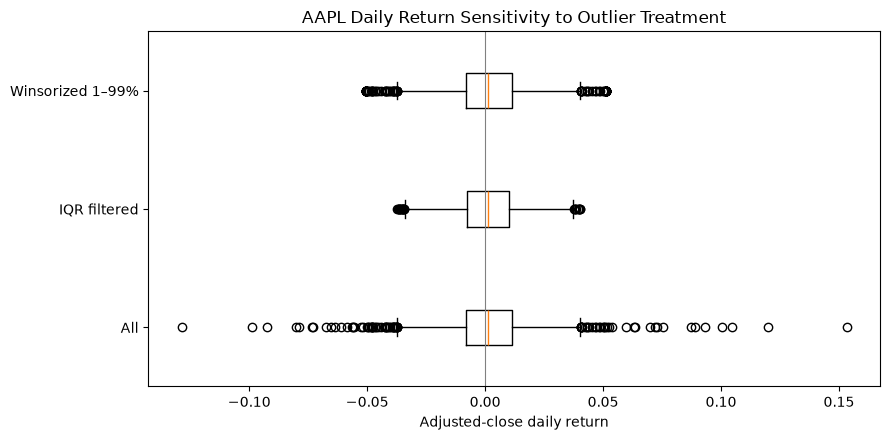

Saved flags: data/processed/aapl_ohlcv_outlier_flags_20200102_20260824.parquet
Saved plot: reports/aapl_daily_return_outlier_sensitivity.png


In [12]:
import matplotlib.pyplot as plt

REPORTS_DIR = get_path('REPORTS_DIR', 'reports', create=True)
plot_values = [
    outlier_data['daily_return'].dropna(),
    outlier_data.loc[~outlier_data['return_outlier_iqr'], 'daily_return'].dropna(),
    winsorize_series(outlier_data['daily_return'], 0.01, 0.99).dropna(),
]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(plot_values, tick_labels=['All', 'IQR filtered', 'Winsorized 1–99%'], orientation='horizontal')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('AAPL Daily Return Sensitivity to Outlier Treatment')
ax.set_xlabel('Adjusted-close daily return')
fig.tight_layout()
outlier_plot_path = REPORTS_DIR / 'aapl_daily_return_outlier_sensitivity.png'
fig.savefig(outlier_plot_path, dpi=150, bbox_inches='tight')
plt.show()

outlier_path = PROCESSED_DIR / f"{SYMBOL.lower()}_ohlcv_outlier_flags_{outlier_data['date'].min():%Y%m%d}_{outlier_data['date'].max():%Y%m%d}.parquet"
write_df(outlier_data, outlier_path)
assert read_df(outlier_path).shape == outlier_data.shape
print('Saved flags:', outlier_path.relative_to(ROOT))
print('Saved plot:', outlier_plot_path.relative_to(ROOT))

### Interpretation, assumptions, and risk

The sensitivity table quantifies how much tail observations influence the return mean and standard deviation. A relatively stable median alongside a lower filtered standard deviation would show that extreme days mainly drive dispersion, which is precisely why deleting them would be dangerous for a volatility project.

IQR is preferred to Z-score for the primary audit because daily returns are heavy-tailed and not reliably normal. However, a global IQR cutoff can mix regimes and uses future sample information; these flags are descriptive annotations, not leakage-safe predictive features. Before treating any flagged row as erroneous, it should be checked against corporate actions and an independent source. Full policy details are in `docs/outliers.md`.

### Stage 07 result

The pipeline now flags extreme adjusted-close returns with two reusable methods, compares three treatments, saves a visual sensitivity artifact, and retains all valid observations for later tail-aware modeling and reporting.

## Stage 08 — Exploratory data analysis

EDA profiles the outlier-annotated dataset without changing its canonical values. It examines structure, missingness, numeric and categorical distributions, contemporaneous relationships, and temporal behavior, then translates those observations into hypotheses for leakage-safe Stage 09 features.

In [13]:
import numpy as np
import seaborn as sns

from src.eda import eda_summary

eda_data = read_df(outlier_path)
eda_data['intraday_range_pct'] = (eda_data['high'] - eda_data['low']) / eda_data['open']
eda_data['log_volume'] = np.log1p(eda_data['volume'])
eda_data['volume_change'] = eda_data['volume'].pct_change(fill_method=None)
eda_data['rolling_vol_21d'] = eda_data['daily_return'].rolling(21).std()

print('DataFrame info:')
eda_data.info()
profile = eda_summary(eda_data)
display(profile['overview'])
display(profile['numeric_summary'].round(4))
display(profile['attention'])

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1669 non-null   datetime64[us]
 1   open                   1669 non-null   float64       
 2   high                   1669 non-null   float64       
 3   low                    1669 non-null   float64       
 4   close                  1669 non-null   float64       
 5   adj_close              1669 non-null   float64       
 6   volume                 1669 non-null   int64         
 7   symbol                 1669 non-null   string        
 8   source                 1669 non-null   string        
 9   daily_return           1668 non-null   float64       
 10  absolute_return        1668 non-null   float64       
 11  return_outlier_iqr     1669 non-null   bool          
 12  return_outlier_zscore  1669 non-null   bool          
 13

,dtype,non_null,missing,missing_pct,unique
date,datetime64[us],1669,0,0.000000,1669
open,float64,1669,0,0.000000,1586
high,float64,1669,0,0.000000,1597
low,float64,1669,0,0.000000,1608
close,float64,1669,0,0.000000,1591
adj_close,float64,1669,0,0.000000,1650
volume,int64,1669,0,0.000000,1667
symbol,string,1669,0,0.000000,1
source,string,1669,0,0.000000,1
daily_return,float64,1668,1,0.000599,1665


,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
open,1669.0,1.781139e+02,5.832990e+01,5.702000e+01,1.385000e+02,1.717300e+02,2.209700e+02,3.400300e+02,1.717300e+02,0.3237,-0.3183
high,1669.0,1.801257e+02,5.884930e+01,5.712500e+01,1.416100e+02,1.734700e+02,2.238100e+02,3.445700e+02,1.734700e+02,0.3328,-0.3050
low,1669.0,1.762819e+02,5.789690e+01,5.315250e+01,1.369300e+02,1.702900e+02,2.189000e+02,3.373500e+02,1.702900e+02,0.3204,-0.3249
close,1669.0,1.782926e+02,5.840740e+01,5.609250e+01,1.389200e+02,1.721000e+02,2.215300e+02,3.400800e+02,1.721000e+02,0.3282,-0.3115
adj_close,1669.0,1.759344e+02,5.925190e+01,5.411700e+01,1.359533e+02,1.689757e+02,2.194900e+02,3.397869e+02,1.689757e+02,0.3476,-0.3314
volume,1669.0,8.125164e+07,5.037099e+07,1.343460e+07,4.856620e+07,6.678130e+07,9.635000e+07,4.265100e+08,6.678130e+07,2.5114,9.1345
daily_return,1668.0,1.100000e-03,1.980000e-02,-1.286000e-01,-8.200000e-03,1.100000e-03,1.120000e-02,1.533000e-01,1.100000e-03,0.2298,6.6249
absolute_return,1668.0,1.370000e-02,1.430000e-02,0.000000e+00,4.400000e-03,9.500000e-03,1.890000e-02,1.533000e-01,9.500000e-03,2.9144,15.0446
intraday_range_pct,1669.0,2.240000e-02,1.290000e-02,5.400000e-03,1.450000e-02,1.910000e-02,2.690000e-02,1.670000e-01,1.910000e-02,2.9228,16.8351
log_volume,1669.0,1.807540e+01,4.992000e-01,1.641330e+01,1.769840e+01,1.801690e+01,1.838350e+01,1.987110e+01,1.801690e+01,0.6111,0.3317


,column,issue,value
0,symbol,near_zero_variance,1.0
1,source,near_zero_variance,1.0


In [14]:
print('Categorical and boolean profiles:')
for column, counts in profile['categorical_profiles'].items():
    print(f'\n{column}')
    display(counts.head(10))

missing_counts = eda_data.isna().sum().sort_values(ascending=False)
display(missing_counts.to_frame('missing_count').head(10))

Categorical and boolean profiles:

date


,count
date,
2020-01-02,1
2020-01-03,1
2020-01-06,1
2020-01-07,1
2020-01-08,1
2020-01-09,1
2020-01-10,1
2020-01-13,1
2020-01-14,1



symbol


,count
symbol,
AAPL,1669



source


...


return_outlier_iqr


,count
return_outlier_iqr,
False,1587
True,82



return_outlier_zscore


,count
return_outlier_zscore,
False,1644
True,25


,missing_count
rolling_vol_21d,21
daily_return,1
volume_change,1
absolute_return,1
log_volume,0
intraday_range_pct,0
return_outlier_zscore,0
return_outlier_iqr,0
date,0
open,0


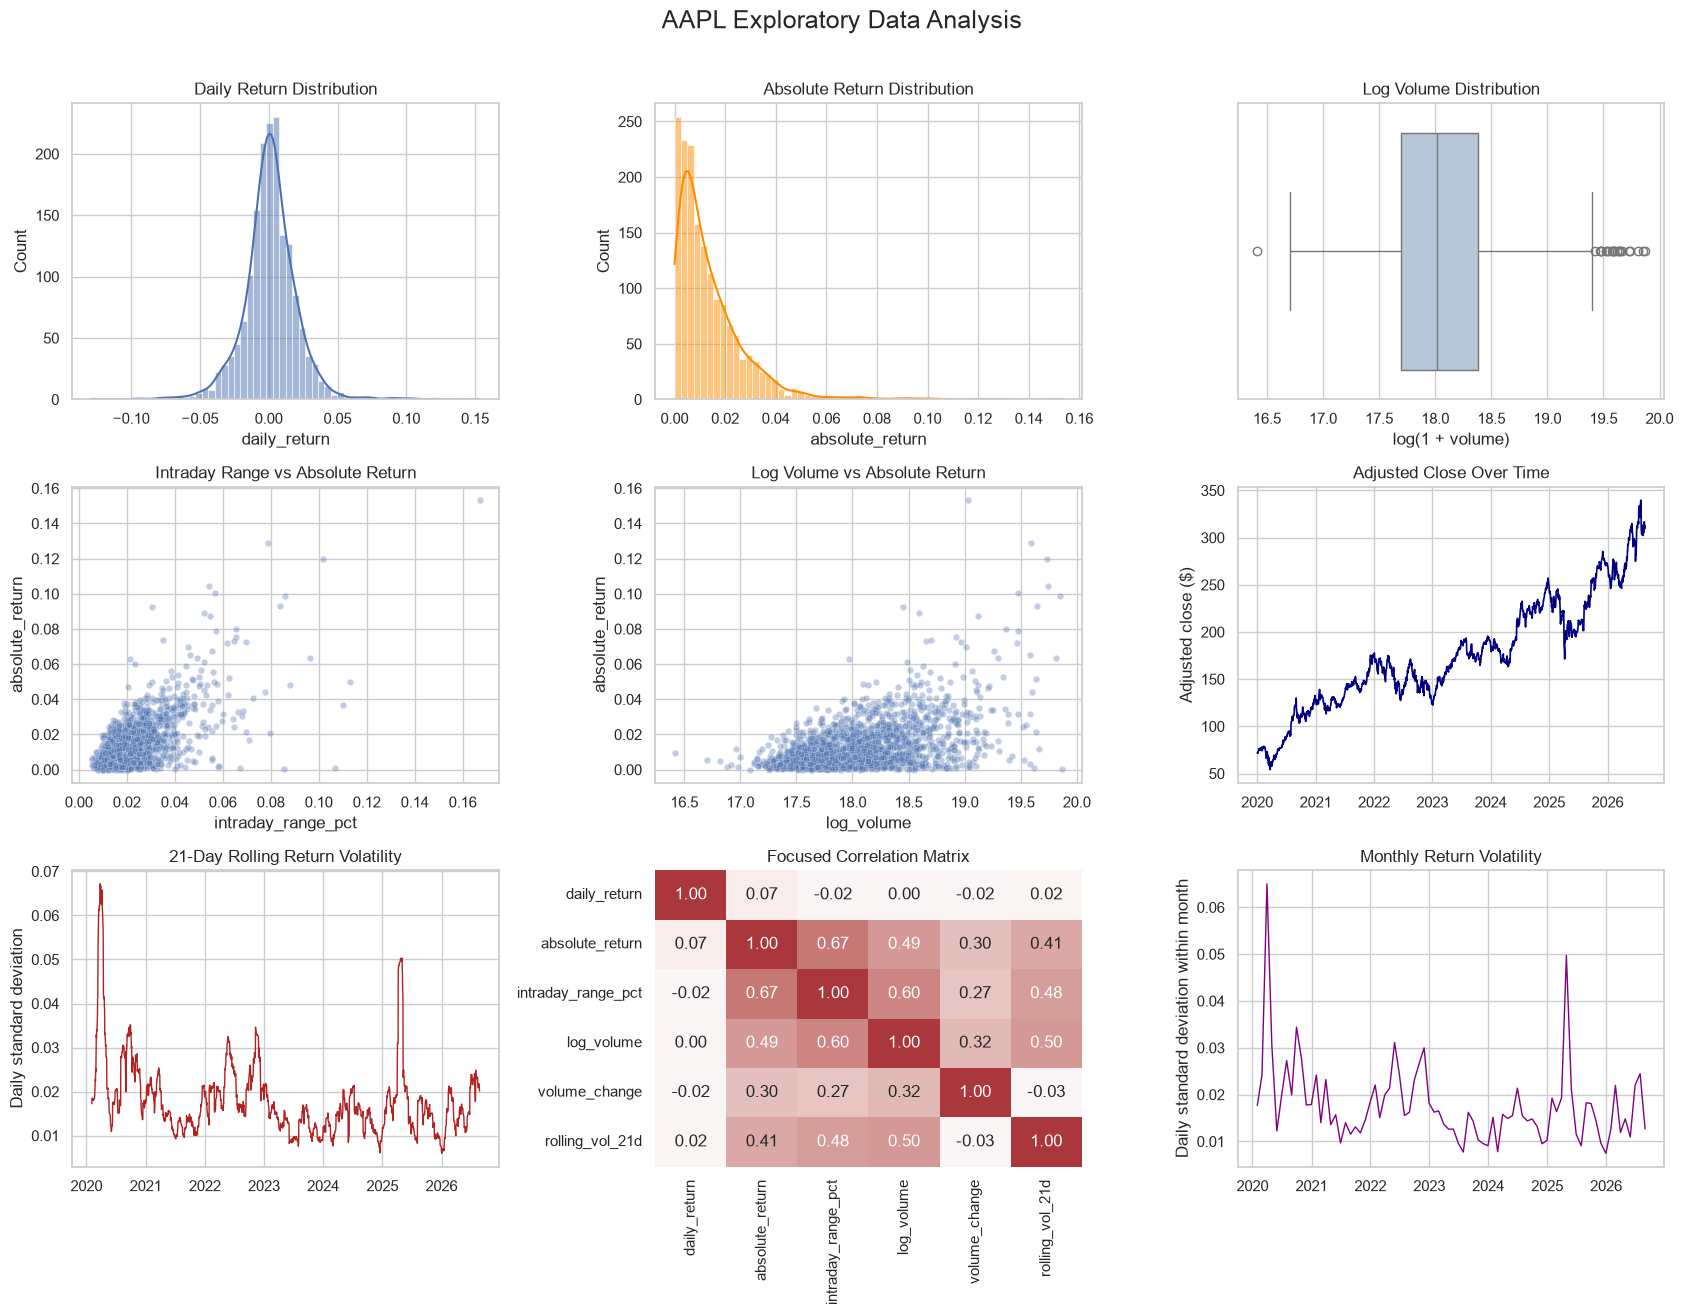

Saved EDA dashboard: reports/aapl_eda_overview.png


In [15]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 3, figsize=(17, 13))

sns.histplot(eda_data['daily_return'], bins=60, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Daily Return Distribution')
sns.histplot(eda_data['absolute_return'], bins=60, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Absolute Return Distribution')
sns.boxplot(x=np.log1p(eda_data['volume']), ax=axes[0, 2], color='lightsteelblue')
axes[0, 2].set_title('Log Volume Distribution')
axes[0, 2].set_xlabel('log(1 + volume)')

sns.scatterplot(data=eda_data, x='intraday_range_pct', y='absolute_return', alpha=0.35, s=22, ax=axes[1, 0])
axes[1, 0].set_title('Intraday Range vs Absolute Return')
sns.scatterplot(data=eda_data, x='log_volume', y='absolute_return', alpha=0.35, s=22, ax=axes[1, 1])
axes[1, 1].set_title('Log Volume vs Absolute Return')
axes[1, 2].plot(eda_data['date'], eda_data['adj_close'], linewidth=1.2, color='navy')
axes[1, 2].set_title('Adjusted Close Over Time')
axes[1, 2].set_ylabel('Adjusted close ($)')

axes[2, 0].plot(eda_data['date'], eda_data['rolling_vol_21d'], linewidth=1.0, color='firebrick')
axes[2, 0].set_title('21-Day Rolling Return Volatility')
axes[2, 0].set_ylabel('Daily standard deviation')
corr_columns = ['daily_return', 'absolute_return', 'intraday_range_pct', 'log_volume', 'volume_change', 'rolling_vol_21d']
focused_correlation = eda_data[corr_columns].corr()
sns.heatmap(focused_correlation, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[2, 1], cbar=False)
axes[2, 1].set_title('Focused Correlation Matrix')
monthly_volatility = eda_data.set_index('date')['daily_return'].resample('ME').std()
axes[2, 2].plot(monthly_volatility.index, monthly_volatility, color='purple', linewidth=1.0)
axes[2, 2].set_title('Monthly Return Volatility')
axes[2, 2].set_ylabel('Daily standard deviation within month')

fig.suptitle('AAPL Exploratory Data Analysis', fontsize=18, y=1.01)
fig.tight_layout()
eda_plot_path = REPORTS_DIR / 'aapl_eda_overview.png'
fig.savefig(eda_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved EDA dashboard:', eda_plot_path.relative_to(ROOT))

In [16]:
key_shape_stats = eda_data[['daily_return', 'absolute_return', 'intraday_range_pct', 'volume']].agg(['skew', 'kurt']).round(3)
target_correlations = focused_correlation['absolute_return'].sort_values(ascending=False).round(3)
highest_volatility_months = monthly_volatility.nlargest(5).round(4)
display(key_shape_stats)
display(target_correlations.to_frame('correlation_with_absolute_return'))
display(highest_volatility_months.to_frame('monthly_volatility'))

,daily_return,absolute_return,intraday_range_pct,volume
skew,0.230,2.914,2.923,2.511
kurt,6.625,15.045,16.835,9.135


,correlation_with_absolute_return
absolute_return,1.000
intraday_range_pct,0.667
log_volume,0.495
rolling_vol_21d,0.409
volume_change,0.300
daily_return,0.074


,monthly_volatility
date,
2020-03-31,0.0650
2025-04-30,0.0497
2020-09-30,0.0344
2022-05-31,0.0311
2020-04-30,0.0306


### Top findings and implications for next step

1. **Returns are heavy-tailed.** Daily return has high excess kurtosis, while absolute return is strongly right-skewed. Median-based summaries and tail-period evaluation should accompany MAE/RMSE; extreme observations should remain available.
2. **Range is a promising volatility signal.** Intraday range percentage has the strongest simple contemporaneous relationship with absolute return (about 0.67). Stage 09 should create lagged range measures; same-day range must not predict a target whose cutoff occurs earlier.
3. **Volume contains weaker but useful structure.** Log volume is moderately related to absolute return (about 0.50), suggesting lagged volume level, change, and rolling-relative-volume features. Log transformation addresses its right skew.
4. **Volatility clusters over time.** The 21-day and monthly plots show clear level shifts, with March 2020 the most volatile month and another major spike in April 2025. Rolling return and volatility features should be fit using prior observations only; random train/test splits are inappropriate.
5. **Price level trends upward and is non-stationary.** Raw adjusted close should not be treated as a directly comparable signal across the full period; returns, ranges, ratios, and lags are more defensible.

**Assumptions and risks:** correlations are descriptive rather than causal; global EDA uses the full sample and cannot itself define production thresholds; symbol/source are intentionally constant provenance fields; and the first return plus rolling-window warm-up values are expected missing values, not ingestion defects.

### Stage 08 result

The project now has reusable EDA summaries, categorical profiles, attention flags, distribution and relationship plots, time-series diagnostics, and concrete leakage-aware hypotheses for feature engineering.

## Stage 09 — Feature engineering

The forecasting cutoff is the current market close. Features on date *t* may use data through that close, while the target is the absolute adjusted-close return on date *t+1*. Rolling windows include the current row, require complete history, and are never backfilled. This explicit alignment prevents future values from leaking into predictors.

In [17]:
from src.features import (
    FEATURE_DEFINITIONS, MODEL_FEATURE_COLUMNS, TARGET_COLUMN,
    build_volatility_features, make_modeling_table,
)

featured_data = build_volatility_features(cleaned_reloaded)
modeling_table = make_modeling_table(featured_data)
feature_dictionary = pd.Series(FEATURE_DEFINITIONS, name='reasoning').to_frame()
display(feature_dictionary)
print('Feature rows before complete-case selection:', len(featured_data))
print('Model-ready rows:', len(modeling_table))
print('Model date range:', modeling_table['date'].min().date(), 'to', modeling_table['date'].max().date())
modeling_table.head()

,reasoning
return_1d,Adjusted-close return known at the current clo...
return_lag_1d,Previous session's adjusted-close return; capt...
absolute_return_1d,Magnitude of the current return; volatility co...
intraday_range_pct,(high - low) / open; Stage 08 found a strong r...
rolling_vol_5d,Five-session return standard deviation; repres...
rolling_vol_21d,Twenty-one-session return standard deviation; ...
rolling_abs_return_5d,Five-session mean absolute return; a robust re...
volume_change_1d,One-session percentage change in volume; captu...
relative_volume_20d,Current volume divided by its trailing 20-sess...
weekday_*,One-hot day-of-week indicators; encode possibl...


Feature rows before complete-case selection: 1669
Model-ready rows: 1647
Model date range: 2020-02-03 to 2026-08-21


,date,return_1d,return_lag_1d,absolute_return_1d,intraday_range_pct,rolling_vol_5d,rolling_vol_21d,rolling_abs_return_5d,volume_change_1d,relative_volume_20d,weekday_mon,weekday_tue,weekday_wed,weekday_thu,weekday_fri,target_next_day_absolute_return
0,2020-02-03,-0.002746,-0.044339,0.002746,0.037036,0.028346,0.017258,0.019551,-0.129266,1.229770,1,0,0,0,0,0.033014
1,2020-02-04,0.033014,-0.002746,0.033014,0.019061,0.029571,0.018360,0.020496,-0.213892,0.960537,0,1,0,0,0,0.008154
2,2020-02-05,0.008154,0.033014,0.008154,0.017959,0.027934,0.018363,0.017941,-0.130216,0.832546,0,0,1,0,0,0.011697
3,2020-02-06,0.011697,0.008154,0.011697,0.015376,0.028548,0.018346,0.019990,-0.112779,0.745614,0,0,0,1,0,0.013592
4,2020-02-07,-0.013592,0.011697,0.013592,0.016751,0.017455,0.018532,0.013841,0.116275,0.848032,0,0,0,0,1,0.004749


In [18]:
assert modeling_table['date'].is_monotonic_increasing
assert not modeling_table.duplicated('date').any()
assert not modeling_table[MODEL_FEATURE_COLUMNS + [TARGET_COLUMN]].isna().any().any()
assert featured_data.iloc[-1][TARGET_COLUMN] != featured_data.iloc[-1][TARGET_COLUMN]  # unknown future target
assert (modeling_table[['weekday_mon', 'weekday_tue', 'weekday_wed', 'weekday_thu', 'weekday_fri']].sum(axis=1) == 1).all()

model_table_path = PROCESSED_DIR / f"{SYMBOL.lower()}_model_features_{modeling_table['date'].min():%Y%m%d}_{modeling_table['date'].max():%Y%m%d}.parquet"
write_df(modeling_table, model_table_path)
modeling_reloaded = read_df(model_table_path)
assert validate_roundtrip(modeling_table, modeling_reloaded, ['date', 'rolling_vol_21d', TARGET_COLUMN])['valid']
print('Saved model-ready features:', model_table_path.relative_to(ROOT))

Saved model-ready features: data/processed/aapl_model_features_20200203_20260821.parquet


,correlation_with_next_day_absolute_return
intraday_range_pct,0.368
rolling_abs_return_5d,0.340
rolling_vol_5d,0.329
rolling_vol_21d,0.310
absolute_return_1d,0.240
relative_volume_20d,0.153
return_lag_1d,-0.109
volume_change_1d,0.091
return_1d,-0.072
weekday_fri,0.050


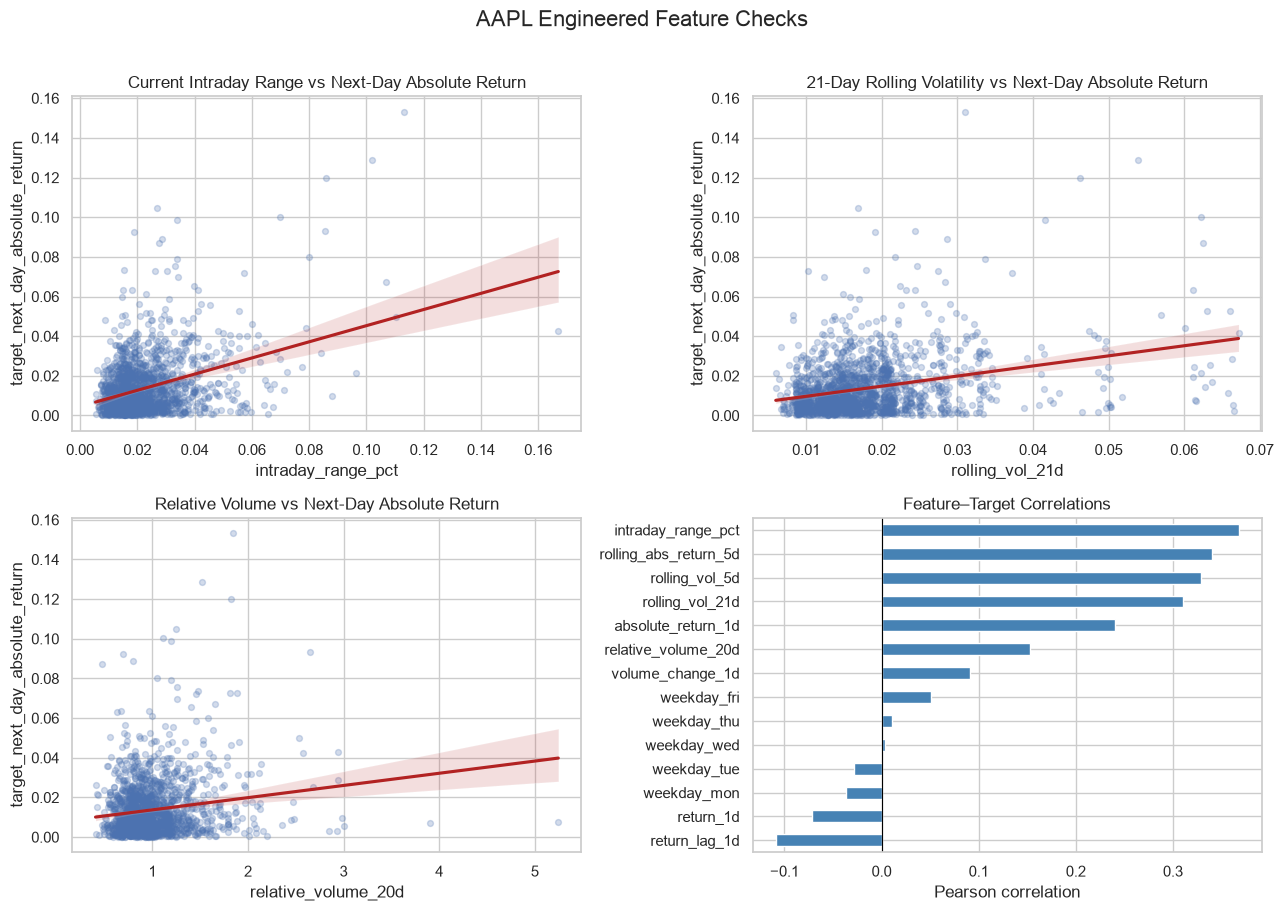

Saved feature relationships: reports/aapl_feature_target_relationships.png


In [19]:
feature_target_correlations = (
    modeling_table[MODEL_FEATURE_COLUMNS + [TARGET_COLUMN]]
    .corr()[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=abs, ascending=False)
)
display(feature_target_correlations.round(3).to_frame('correlation_with_next_day_absolute_return'))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
relationship_features = [
    ('intraday_range_pct', 'Current Intraday Range'),
    ('rolling_vol_21d', '21-Day Rolling Volatility'),
    ('relative_volume_20d', 'Relative Volume'),
]
for ax, (feature, title) in zip(axes.flat[:3], relationship_features):
    sns.regplot(data=modeling_table, x=feature, y=TARGET_COLUMN, scatter_kws={'alpha': 0.25, 's': 18}, line_kws={'color': 'firebrick'}, ax=ax)
    ax.set_title(f'{title} vs Next-Day Absolute Return')
feature_target_correlations.sort_values().plot.barh(ax=axes[1, 1], color='steelblue')
axes[1, 1].axvline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Feature–Target Correlations')
axes[1, 1].set_xlabel('Pearson correlation')
fig.suptitle('AAPL Engineered Feature Checks', fontsize=16, y=1.01)
fig.tight_layout()
feature_plot_path = REPORTS_DIR / 'aapl_feature_target_relationships.png'
fig.savefig(feature_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature relationships:', feature_plot_path.relative_to(ROOT))

### Feature rationale, assumptions, and risks

- **Recent returns and volatility:** current/lagged return, absolute return, and 5/21-day trailing summaries express the Stage 08 finding that volatility clusters over time.
- **Range:** normalized intraday range translates the strongest same-day EDA relationship into a feature available at the current close for forecasting the next session.
- **Volume:** percentage change and trailing-relative volume address the skew and changing scale observed in EDA.
- **Categorical encoding:** five explicit weekday indicators avoid imposing a false numeric order on the calendar and guarantee a stable schema.

Correlation checks are screening tools, not evidence of stable predictive value or causality. Rolling warm-up rows and the final unknown target are removed only from the model-ready table. Scaling and feature selection must be fitted inside each time-ordered training fold. Full-sample outlier flags are excluded because they would leak global distribution information.

### Stage 09 result

The pipeline now creates, documents, checks, visualizes, and saves a chronological model-ready feature table for next-day absolute-return forecasting. The reusable module fixes the target alignment and feature schema for the upcoming modeling stages.

## Stage 10a — Time-aware regression baseline

This stage fits a transparent regression baseline for next-day absolute return. The first 80% of observations form the training period and the final 20% form a single untouched test period; no rows are shuffled. Within the training period, the final 20% is a chronological validation window used to compare standardized OLS with Ridge variations. The selected specification is then refit on all training observations and evaluated once on the holdout.

Thirteen Stage 09 predictors are retained because each is available by the current close and represents recent return, range, trailing volatility, volume, or calendar information. `weekday_fri` is omitted as the reference category, avoiding perfect multicollinearity between all five weekday indicators and the model intercept. Standardization is learned inside each training fit, addressing scale differences without using future distribution information. Ridge variations address correlated volatility proxies and potentially unstable OLS coefficients. The response is non-negative and right-skewed, so predictions are clipped at zero for operational interpretation; MAE is primary, while RMSE, R², tail MAE, and comparison with the 21-day rolling-volatility baseline provide complementary diagnostics.

In [20]:
from src.modeling import (
    chronological_train_test_split, evaluate_holdout, regression_candidates,
    select_regression_model, standardized_coefficients,
)

model_split = chronological_train_test_split(modeling_table, train_fraction=0.8)
selected_name, fitted_model, validation_comparison = select_regression_model(
    model_split.train, candidates=regression_candidates(alphas=(0.01, 0.1, 1.0, 10.0, 100.0))
)
holdout_metrics, prediction_errors = evaluate_holdout(fitted_model, model_split)
coefficient_table = standardized_coefficients(fitted_model, model_split.feature_columns)
baseline_mae = holdout_metrics.loc[holdout_metrics['method'].eq('rolling_vol_21d_baseline'), 'mae'].iloc[0]
model_mae = holdout_metrics.loc[holdout_metrics['method'].eq('selected_regression'), 'mae'].iloc[0]
mae_improvement_pct = 100 * (baseline_mae - model_mae) / baseline_mae

print(f'Train: {model_split.train.date.min().date()} to {model_split.train.date.max().date()} ({len(model_split.train):,} rows)')
print(f'Test:  {model_split.test.date.min().date()} to {model_split.test.date.max().date()} ({len(model_split.test):,} rows)')
print('Selected model:', selected_name)
print(f'Holdout MAE improvement vs baseline: {mae_improvement_pct:.2f}%')
display(validation_comparison.round(6))
display(holdout_metrics.round(6))
display(coefficient_table.round(6))

Train: 2020-02-03 to 2025-04-29 (1,317 rows)
Test:  2025-04-30 to 2026-08-21 (330 rows)
Selected model: ridge_alpha_100
Holdout MAE improvement vs baseline: 19.40%


,model,mae,rmse,r2
0,ridge_alpha_100,0.009513,0.014209,0.162771
1,ridge_alpha_10,0.009548,0.014245,0.158459
2,ridge_alpha_1,0.009551,0.014252,0.157644
3,ridge_alpha_0.1,0.009551,0.014253,0.157553
4,ridge_alpha_0.01,0.009551,0.014253,0.157543
5,ols,0.009551,0.014253,0.157542


,method,mae,rmse,r2,tail_mae,tail_threshold,tail_observations
0,selected_regression,0.008453,0.011364,-0.014671,0.020958,0.022463,42
1,rolling_vol_21d_baseline,0.010488,0.013247,-0.378802,0.019124,0.022463,42


,feature,standardized_coefficient,absolute_coefficient
0,intraday_range_pct,0.003443,0.003443
1,rolling_vol_21d,0.001946,0.001946
2,return_lag_1d,-0.001379,0.001379
3,rolling_abs_return_5d,0.001228,0.001228
4,return_1d,-0.001027,0.001027
5,rolling_vol_5d,0.000710,0.000710
6,weekday_mon,-0.000681,0.000681
7,absolute_return_1d,-0.000617,0.000617
8,weekday_tue,-0.000531,0.000531
9,weekday_thu,-0.000396,0.000396


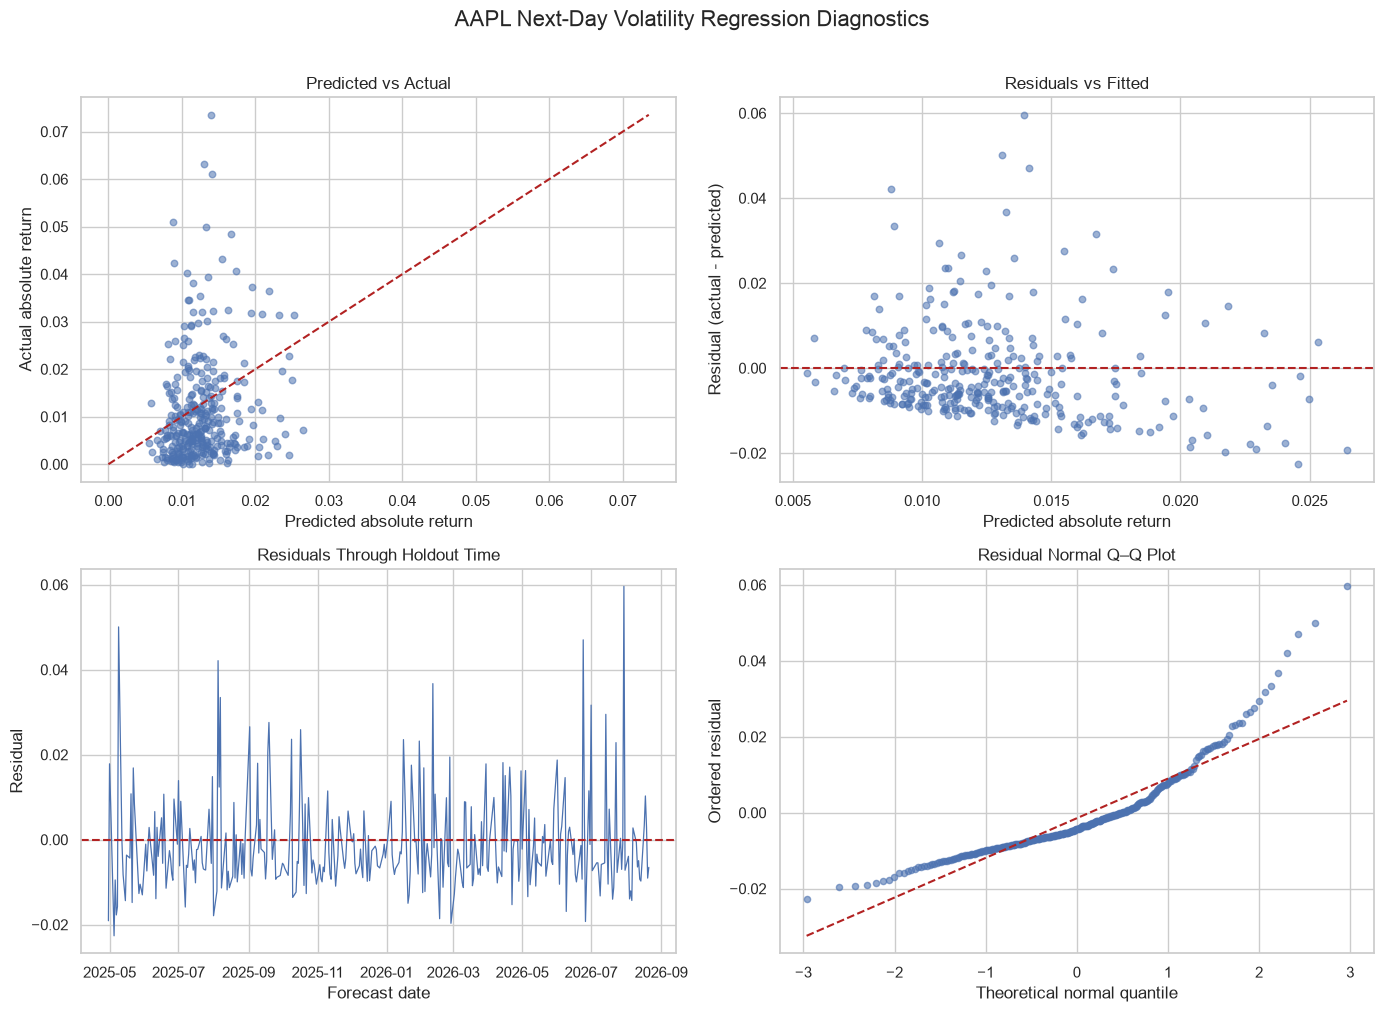

Saved regression diagnostics and tables under: reports


In [21]:
from statistics import NormalDist

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(prediction_errors['prediction'], prediction_errors['actual'], alpha=0.55, s=22)
limit = prediction_errors[['prediction', 'actual']].to_numpy().max()
axes[0, 0].plot([0, limit], [0, limit], '--', color='firebrick')
axes[0, 0].set(title='Predicted vs Actual', xlabel='Predicted absolute return', ylabel='Actual absolute return')

axes[0, 1].scatter(prediction_errors['prediction'], prediction_errors['residual'], alpha=0.55, s=22)
axes[0, 1].axhline(0, linestyle='--', color='firebrick')
axes[0, 1].set(title='Residuals vs Fitted', xlabel='Predicted absolute return', ylabel='Residual (actual - predicted)')

axes[1, 0].plot(prediction_errors['date'], prediction_errors['residual'], linewidth=0.9)
axes[1, 0].axhline(0, linestyle='--', color='firebrick')
axes[1, 0].set(title='Residuals Through Holdout Time', xlabel='Forecast date', ylabel='Residual')

sorted_residuals = np.sort(prediction_errors['residual'].to_numpy())
probabilities = (np.arange(1, len(sorted_residuals) + 1) - 0.5) / len(sorted_residuals)
theoretical = np.array([NormalDist().inv_cdf(value) for value in probabilities])
axes[1, 1].scatter(theoretical, sorted_residuals, alpha=0.6, s=20)
qq_slope, qq_intercept = np.polyfit(theoretical, sorted_residuals, 1)
axes[1, 1].plot(theoretical, qq_intercept + qq_slope * theoretical, '--', color='firebrick')
axes[1, 1].set(title='Residual Normal Q–Q Plot', xlabel='Theoretical normal quantile', ylabel='Ordered residual')
fig.suptitle('AAPL Next-Day Volatility Regression Diagnostics', fontsize=16, y=1.01)
fig.tight_layout()
diagnostic_path = REPORTS_DIR / 'aapl_regression_diagnostics.png'
fig.savefig(diagnostic_path, dpi=150, bbox_inches='tight')
plt.show()

validation_comparison.to_csv(REPORTS_DIR / 'aapl_regression_validation.csv', index=False)
holdout_metrics.assign(mae_improvement_vs_baseline_pct=[mae_improvement_pct, 0.0]).to_csv(
    REPORTS_DIR / 'aapl_regression_holdout_metrics.csv', index=False
)
coefficient_table.to_csv(REPORTS_DIR / 'aapl_regression_coefficients.csv', index=False)
print('Saved regression diagnostics and tables under:', REPORTS_DIR.relative_to(ROOT))

In [22]:
largest_positive = coefficient_table.sort_values('standardized_coefficient', ascending=False).iloc[0]
largest_negative = coefficient_table.sort_values('standardized_coefficient').iloc[0]
residual_mean = prediction_errors['residual'].mean()
residual_target_correlation = prediction_errors[['actual', 'residual']].corr().iloc[0, 1]
print(f'Largest positive standardized coefficient: {largest_positive.feature} ({largest_positive.standardized_coefficient:.6f})')
print(f'Largest negative standardized coefficient: {largest_negative.feature} ({largest_negative.standardized_coefficient:.6f})')
print(f'Mean residual: {residual_mean:.6f}')
print(f'Actual–residual correlation: {residual_target_correlation:.3f}')
print('Positive coefficients raise the conditional next-day magnitude forecast; negative coefficients lower it, holding other standardized inputs fixed.')

Largest positive standardized coefficient: intraday_range_pct (0.003443)
Largest negative standardized coefficient: return_lag_1d (-0.001379)
Mean residual: -0.001461
Actual–residual correlation: 0.945
Positive coefficients raise the conditional next-day magnitude forecast; negative coefficients lower it, holding other standardized inputs fixed.


### Assumptions, coefficient meaning, and risk-aware interpretation

Linear regression assumes an approximately linear conditional relationship, independent/weakly dependent errors, stable coefficients, roughly constant error variance, and sufficiently well-behaved residuals for classical inference. Financial volatility challenges several of these assumptions: the target is bounded at zero and right-skewed, residual variance can change by regime, adjacent errors may be dependent, and rolling predictors are correlated. Standardization improves numerical comparability and Ridge shrinkage can stabilize correlated coefficients, but neither proves the assumptions. The Q–Q, residual–fitted, and time plots expose skew, heteroskedasticity, outliers, and regime clusters rather than concealing them.

Coefficients are expressed per one training-period standard deviation increase in a feature, holding other inputs fixed. They describe conditional associations, not causal effects or guaranteed trading signals. Calendar indicators are interpreted relative to Friday, the omitted reference category, and the other features; correlated volatility measures can divide or reverse coefficient weight, so direction and magnitude must be read cautiously.

MAE is the primary operational metric because it is in absolute-return units and is less dominated by shocks than RMSE. RMSE highlights costly large misses; R² can be negative out of sample and should not be treated as a deployment verdict by itself. Tail MAE uses the training target's 80th percentile, preventing the test period from defining its own risk threshold. A favorable average does not authorize automated hedging: the analyst should review tail underprediction, regime change, concentration, costs, and portfolio context. This is a first holdout baseline; later stages should use repeated expanding-window evaluation before claiming stable performance.

### Stage 10a result

The pipeline now automates a leakage-aware comparison of OLS and Ridge regressions, refits the selected candidate on the complete training period, evaluates one untouched chronological holdout against the rolling-volatility baseline, reports standardized coefficients and tail error, and saves reproducible residual diagnostics.

## Stage 10b — Expanding-window regression backtest

Stage 10a's single holdout can be unusually favorable or unfavorable. This stage keeps the regression track and adds a repeated expanding-window backtest. The first 600 observations form the minimum history; each subsequent non-overlapping block of up to 200 sessions is forecast exactly once. At every fold, OLS and Ridge variations are selected using only that fold's historical training data, after which the scaler and selected model are refit on the full expanding history.

The same leakage-safe lag, rolling, range, volume, and calendar features are reused through the sklearn Pipeline. Nothing is recomputed from a future test block. The tail threshold is also estimated separately from each fold's training target, making the high-volatility diagnostic available at the real forecast cutoff.

In [23]:
from src.modeling import expanding_window_backtest, regression_metrics

walk_forward_folds, walk_forward_predictions = expanding_window_backtest(
    modeling_table,
    initial_train_size=600,
    test_size=200,
    candidates=regression_candidates(alphas=(0.01, 0.1, 1.0, 10.0, 100.0)),
)
walk_forward_model_metrics = regression_metrics(
    walk_forward_predictions['actual'], walk_forward_predictions['prediction']
)
walk_forward_baseline_metrics = regression_metrics(
    walk_forward_predictions['actual'], walk_forward_predictions['baseline']
)
tail_predictions = walk_forward_predictions.loc[walk_forward_predictions['is_tail']]
walk_forward_summary = pd.DataFrame([
    {'method': 'selected_regression', **walk_forward_model_metrics,
     'tail_mae': tail_predictions['absolute_error'].mean()},
    {'method': 'rolling_vol_21d_baseline', **walk_forward_baseline_metrics,
     'tail_mae': tail_predictions['baseline_absolute_error'].mean()},
])
walk_forward_improvement_pct = 100 * (
    walk_forward_baseline_metrics['mae'] - walk_forward_model_metrics['mae']
) / walk_forward_baseline_metrics['mae']
assert walk_forward_predictions['date'].is_unique
assert walk_forward_predictions['date'].is_monotonic_increasing
assert (walk_forward_folds['train_end'] < walk_forward_folds['test_start']).all()
print(f'Walk-forward coverage: {walk_forward_predictions.date.min().date()} to {walk_forward_predictions.date.max().date()} ({len(walk_forward_predictions):,} forecasts)')
print(f'Folds: {len(walk_forward_folds)}; aggregate MAE improvement vs baseline: {walk_forward_improvement_pct:.2f}%')
display(walk_forward_folds.style.format(precision=6))
display(walk_forward_summary.round(6))

Walk-forward coverage: 2022-06-21 to 2026-08-21 (1,047 forecasts)
Folds: 6; aggregate MAE improvement vs baseline: 14.70%


,fold,selected_model,train_start,train_end,test_start,test_end,train_rows,test_rows,model_mae,model_rmse,model_r2,baseline_mae,baseline_rmse,baseline_r2,model_tail_mae,baseline_tail_mae,tail_threshold,tail_observations
0,1,ridge_alpha_100,2020-02-03 00:00:00,2022-06-17 00:00:00,2022-06-21 00:00:00,2023-04-05 00:00:00,600,200,0.009872,0.013162,-0.023118,0.011330,0.014415,-0.227161,0.020676,0.017266,0.026133,33
1,2,ridge_alpha_100,2020-02-03 00:00:00,2023-04-05 00:00:00,2023-04-06 00:00:00,2024-01-23 00:00:00,800,200,0.006550,0.008634,-0.118700,0.007083,0.008961,-0.205090,0.023283,0.023598,0.025600,9
2,3,ols,2020-02-03 00:00:00,2024-01-23 00:00:00,2024-01-24 00:00:00,2024-11-06 00:00:00,1000,200,0.008002,0.010777,-0.110947,0.008853,0.011432,-0.250199,0.023834,0.022652,0.023753,16
3,4,ols,2020-02-03 00:00:00,2024-11-06 00:00:00,2024-11-07 00:00:00,2025-08-27 00:00:00,1200,200,0.010089,0.015313,0.173781,0.012706,0.018766,-0.240928,0.021834,0.022044,0.022552,33
4,5,ridge_alpha_100,2020-02-03 00:00:00,2025-08-27 00:00:00,2025-08-28 00:00:00,2026-06-15 00:00:00,1400,200,0.007598,0.009654,0.048781,0.008980,0.010812,-0.193237,0.017989,0.016619,0.021889,26
5,6,ridge_alpha_100,2020-02-03 00:00:00,2026-06-15 00:00:00,2026-06-16 00:00:00,2026-08-21 00:00:00,1600,47,0.010267,0.015414,-0.057098,0.013821,0.016957,-0.279316,0.025296,0.019883,0.021363,9


,method,mae,rmse,r2,tail_mae
0,selected_regression,0.008505,0.011949,0.069821,0.021342
1,rolling_vol_21d_baseline,0.009971,0.013510,-0.189039,0.019707


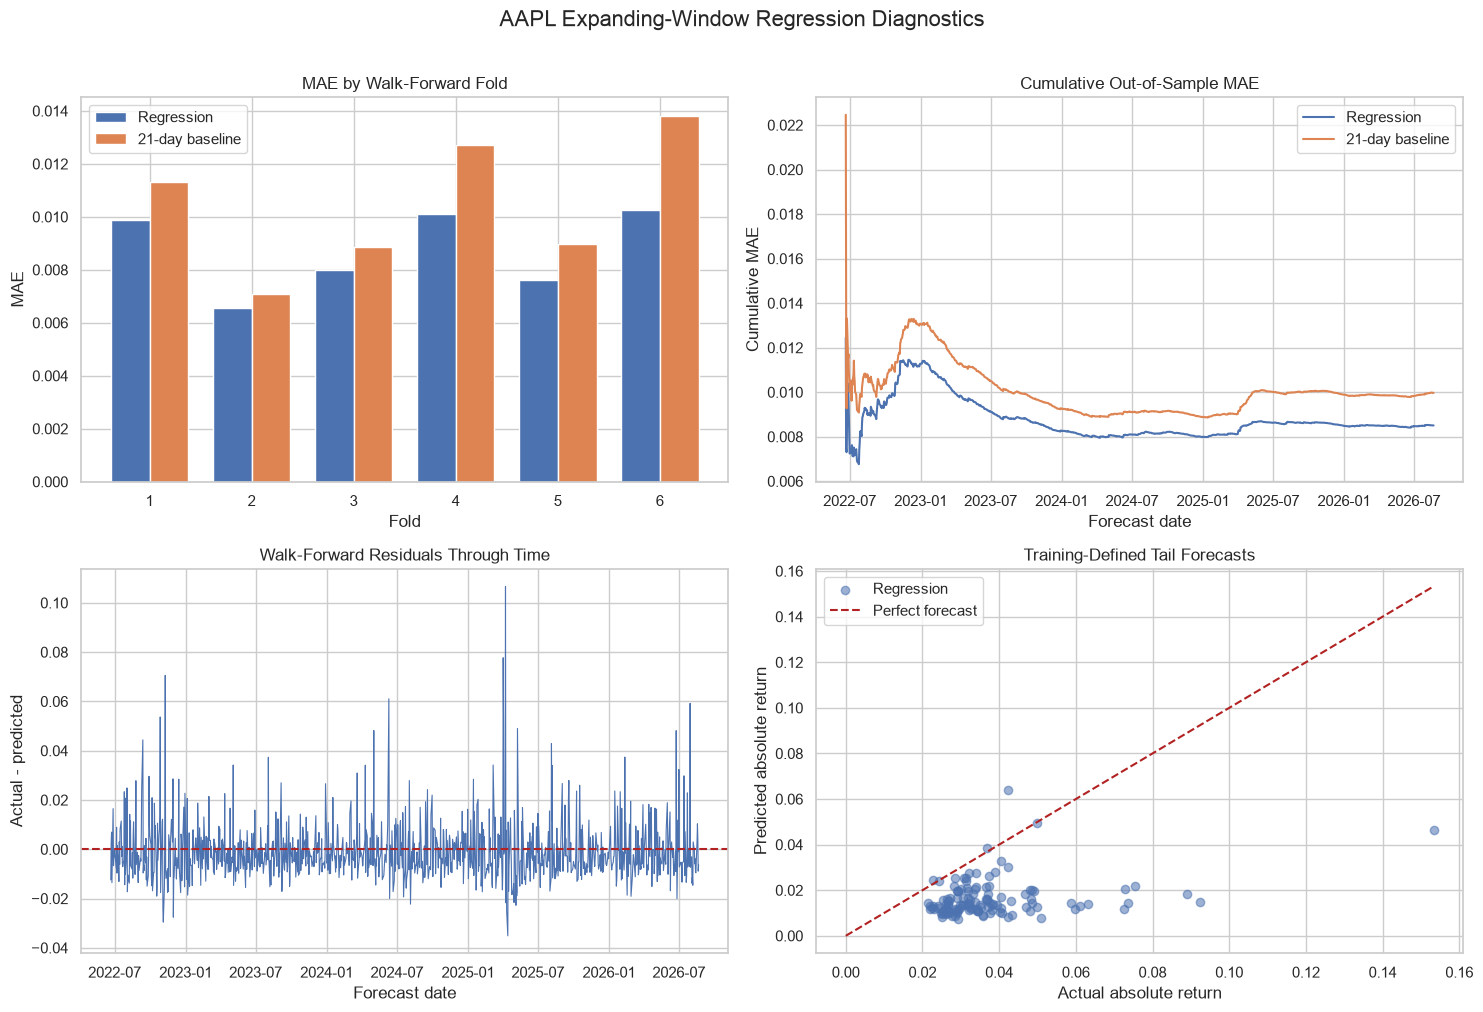

Saved walk-forward diagnostics and tables under: reports


In [24]:
walk_forward_predictions['cumulative_model_mae'] = walk_forward_predictions['absolute_error'].expanding().mean()
walk_forward_predictions['cumulative_baseline_mae'] = walk_forward_predictions['baseline_absolute_error'].expanding().mean()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x = np.arange(len(walk_forward_folds))
width = 0.38
axes[0, 0].bar(x - width / 2, walk_forward_folds['model_mae'], width, label='Regression')
axes[0, 0].bar(x + width / 2, walk_forward_folds['baseline_mae'], width, label='21-day baseline')
axes[0, 0].set_xticks(x, walk_forward_folds['fold'])
axes[0, 0].set(title='MAE by Walk-Forward Fold', xlabel='Fold', ylabel='MAE')
axes[0, 0].legend()

axes[0, 1].plot(walk_forward_predictions['date'], walk_forward_predictions['cumulative_model_mae'], label='Regression')
axes[0, 1].plot(walk_forward_predictions['date'], walk_forward_predictions['cumulative_baseline_mae'], label='21-day baseline')
axes[0, 1].set(title='Cumulative Out-of-Sample MAE', xlabel='Forecast date', ylabel='Cumulative MAE')
axes[0, 1].legend()

axes[1, 0].plot(walk_forward_predictions['date'], walk_forward_predictions['residual'], linewidth=0.8)
axes[1, 0].axhline(0, linestyle='--', color='firebrick')
axes[1, 0].set(title='Walk-Forward Residuals Through Time', xlabel='Forecast date', ylabel='Actual - predicted')

axes[1, 1].scatter(tail_predictions['actual'], tail_predictions['prediction'], alpha=0.55, label='Regression')
tail_limit = tail_predictions[['actual', 'prediction', 'baseline']].to_numpy().max()
axes[1, 1].plot([0, tail_limit], [0, tail_limit], '--', color='firebrick', label='Perfect forecast')
axes[1, 1].set(title='Training-Defined Tail Forecasts', xlabel='Actual absolute return', ylabel='Predicted absolute return')
axes[1, 1].legend()
fig.suptitle('AAPL Expanding-Window Regression Diagnostics', fontsize=16, y=1.01)
fig.tight_layout()
walk_forward_plot_path = REPORTS_DIR / 'aapl_walk_forward_diagnostics.png'
fig.savefig(walk_forward_plot_path, dpi=150, bbox_inches='tight')
plt.show()
walk_forward_folds.to_csv(REPORTS_DIR / 'aapl_walk_forward_folds.csv', index=False)
walk_forward_summary.assign(mae_improvement_vs_baseline_pct=[walk_forward_improvement_pct, 0.0]).to_csv(
    REPORTS_DIR / 'aapl_walk_forward_summary.csv', index=False
)
print('Saved walk-forward diagnostics and tables under:', REPORTS_DIR.relative_to(ROOT))

In [25]:
fold_wins = int((walk_forward_folds['model_mae'] < walk_forward_folds['baseline_mae']).sum())
selection_counts = walk_forward_folds['selected_model'].value_counts()
tail_change_pct = 100 * (
    walk_forward_summary.loc[0, 'tail_mae'] - walk_forward_summary.loc[1, 'tail_mae']
) / walk_forward_summary.loc[1, 'tail_mae']
print(f'Regression beats the baseline in {fold_wins}/{len(walk_forward_folds)} folds.')
print('Per-fold selected models:')
display(selection_counts.rename('folds').to_frame())
print(f'Regression tail MAE change vs baseline: {tail_change_pct:+.2f}%')

Regression beats the baseline in 6/6 folds.
Per-fold selected models:


,folds
selected_model,
ridge_alpha_100,4
ols,2


Regression tail MAE change vs baseline: +8.30%


### Walk-forward assumptions and risk interpretation

Expanding-window evaluation assumes older observations remain useful as the history grows. It is more realistic than random cross-validation for this forecast cutoff, but it does not eliminate regime change, dependence, heteroskedasticity, or vendor revision risk. Fixed 200-session blocks trade temporal detail for stable fold metrics; a different initial history or block size can change conclusions. Repeated model selection also means coefficients can vary across folds, so Stage 10a's full-training coefficients are explanations of one fitted model rather than permanent market relationships.

The aggregate MAE weights every forecast equally and may hide a weak regime. Fold MAE exposes time instability, cumulative MAE shows whether apparent gains persist, and training-defined tail MAE focuses on the large moves relevant to the risk analyst. Residual and tail plots diagnose systematic underprediction, but no backtest measures transaction costs or portfolio-specific loss. A model that wins on average but loses in tail periods should remain advisory and must not automate hedging or exposure changes.

### Stage 10b result

The project now has a reusable expanding-window backtest that rebuilds its sklearn Pipeline, model choice, scaling, and tail threshold using only the history available at each fold. It evaluates every post-warm-up observation once, compares regression with the same risk baseline across regimes, and saves fold-level and aggregate prediction-error diagnostics.